ERA5-Land is a reanalysis dataset providing a consistent view of the evolution of land variables over several decades at an enhanced resolution compared to ERA5. ERA5-Land has been produced by replaying the land component of the ECMWF ERA5 climate reanalysis. Reanalysis combines model data with observations from across the world into a globally complete and consistent dataset using the laws of physics. Reanalysis produces data that goes several decades back in time, providing an accurate description of the climate of the past.\
https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-land?tab=overview

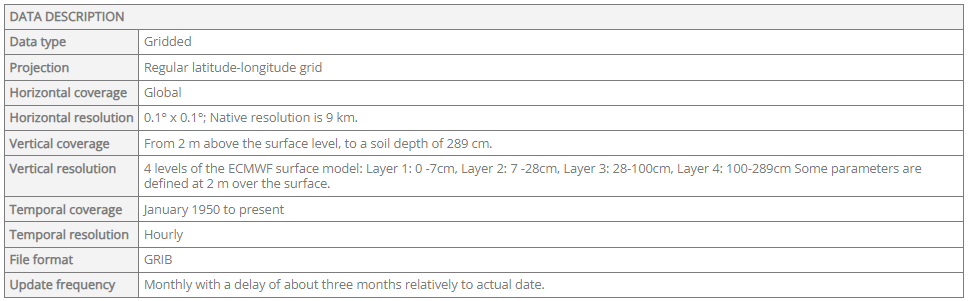

Using cdsapi (https://cds.climate.copernicus.eu/api-how-to) to get data really take more time than I was except, so I prefer using Earth Engine Data Catalog.

In [1]:
!pip install earthengine-api --quiet

In [76]:
import ee
import pandas as pd
import time
import os
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the Earth Engine API.
ee.Initialize()

Enter verification code:  4/1Adeu5BX1WRDEzS0uDgawTDPmuTDeYmmI_AdiMViEN6LqXoG8IWW88IV9oLI



Successfully saved authorization token.


In [77]:
import ee
import pandas as pd

def get_era5land_data(year, dataset_path, r_lon, r_lat, variables, show_variable_names=False):
    
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    # Load the ERA5-Land dataset.
    era5land = ee.ImageCollection(dataset_path)
    # Definition of the location of interest with a point
    r_poi = ee.Geometry.Point(r_lon, r_lat)

    # here is the buffer zone we consider around each point: 1m
    buffer_points = 1 

    # Filter the dataset by region and time period.
    filtered_era5land = era5land.select(variables).filterDate(start_date, end_date)

    if show_variable_names:
        
        # Get the first image from the filtered collection
        first_image = ee.Image(filtered_era5land.first())
        
        # Get the list of variable (band) names in the first image
        variable_names = first_image.bandNames().getInfo()
        
        # Print the list of variable names
        print(variable_names)

    df = pd.DataFrame(filtered_era5land.getRegion(r_poi, buffer_points).getInfo())
    headers = df.iloc[0]
    df = pd.DataFrame(df.values[1:], columns=headers)

    # Convert the datetime strings to datetime objects

    df['datetime'] = pd.to_datetime(df['time'], unit='ms')

    # Reorder columns with 'datetime' at the first place
    cols = ['datetime'] + [col for col in df if col != 'datetime']
    df = df[cols]
    #drop id and time columns
    df = df.drop(columns=["id", "time"])
    
    return df


In [81]:

era5_land_dataset_path = "ECMWF/ERA5_LAND/HOURLY" #https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_HOURLY#bands
r_lon = -16.4535
r_lat = 14.495810
variables = ['volumetric_soil_water_layer_1', 
             'volumetric_soil_water_layer_2', 
             'volumetric_soil_water_layer_3', 
             'volumetric_soil_water_layer_4',  
             'evaporation_from_the_top_of_canopy', 
             'evaporation_from_vegetation_transpiration', 
             'potential_evaporation', 
             'total_evaporation',  
             'total_precipitation', 
             'leaf_area_index_high_vegetation', 
             'leaf_area_index_low_vegetation', 
             'evaporation_from_the_top_of_canopy_hourly', 
             'evaporation_from_vegetation_transpiration_hourly', 
             'potential_evaporation_hourly',
             'total_evaporation_hourly', 
             'total_precipitation_hourly']

# Create a directory to save CSV files if it doesn't exist
output_directory = "ERA5_HOURLY"
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through the years and append dataframes
dataframes = []  # Initialize an empty DataFrame
count=0
year_issue = []
for year in range(1950, 2023):
    try:
        print(year)
        year_df = get_era5land_data(year, era5_land_dataset_path, r_lon, r_lat, variables, show_variable_names=False)
        dataframes.append(year_df)
        # Save DataFrame to CSV file
        csv_filename = os.path.join(output_directory, f"{year}_ERA5_dataset.csv")
        year_df.to_csv(csv_filename, index=False)
        
        count+=1
        if count == 10:
            print("Taking a 3-minute break...")
            time.sleep(360)  # 2 minutes in seconds
            print("Continuing after the break.")
            count=0
    except:
        print(f"Stop at {year}: User memory limit exceeded.")
        year_issue.append(year)

print(year_issue)

2012


In [ ]:
combined_df.to_csv(os.path.join(output_directory, f"ERA5_dataset.csv"), index=False)

In [98]:
import os
import pandas as pd

# Directory where the CSV files are located
directory = os.getcwd()+"/ERA5_HOURLY"

# Get a list of all CSV files in the directory
csv_files = [file for file in os.listdir(directory) if file.endswith('dataset.csv')]

# Initialize an empty list to store DataFrames
dataframes = []

# Loop through each CSV file, read it into a DataFrame, and append to the list
for csv_file in csv_files:
    file_path = os.path.join(directory, csv_file)
    df = pd.read_csv(file_path)
    dataframes.append(df)

# Concatenate all DataFrames into a single DataFrame
final_dataframe = pd.concat(dataframes, ignore_index=True)
final_dataframe.to_csv(os.path.join(directory, f"ERA5_dataset.csv"), index=False)




In [99]:
final_dataframe.head()

,datetime,longitude,latitude,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,evaporation_from_the_top_of_canopy,evaporation_from_vegetation_transpiration,potential_evaporation,total_evaporation,total_precipitation,leaf_area_index_high_vegetation,leaf_area_index_low_vegetation,evaporation_from_the_top_of_canopy_hourly,evaporation_from_vegetation_transpiration_hourly,potential_evaporation_hourly,total_evaporation_hourly,total_precipitation_hourly
0,1950-01-01 01:00:00,-16.453502,14.495813,0.189346,0.209335,0.229904,0.205703,0.0,0.000000e+00,-0.000336,-0.000002,0.0,0.0,0.882568,0.0,0.000000e+00,-0.000336,-0.000002,0.0
1,1950-01-01 02:00:00,-16.453502,14.495813,0.189346,0.209335,0.229904,0.205703,0.0,0.000000e+00,-0.000656,-0.000004,0.0,0.0,0.882568,0.0,0.000000e+00,-0.000320,-0.000002,0.0
2,1950-01-01 03:00:00,-16.453502,14.495813,0.189331,0.209335,0.229904,0.205703,0.0,1.164153e-10,-0.000969,-0.000006,0.0,0.0,0.882568,0.0,1.164153e-10,-0.000313,-0.000002,0.0
3,1950-01-01 04:00:00,-16.453502,14.495813,0.189331,0.209335,0.229904,0.205703,0.0,0.000000e+00,-0.001263,-0.000008,0.0,0.0,0.882568,0.0,-1.164153e-10,-0.000295,-0.000002,0.0
4,1950-01-01 05:00:00,-16.453502,14.495813,0.189316,0.209335,0.229904,0.205703,0.0,0.000000e+00,-0.001534,-0.000010,0.0,0.0,0.882568,0.0,0.000000e+00,-0.000271,-0.000002,0.0
